# 🛡️ Cybersecurity Threat Classification: ML for Cyber Defence

**Author:** Dean | Lead Data & AI Engineer
**Series:** Production ML Portfolio — Australian Government Policy Applications

## Government Context
- **ASD (Australian Signals Directorate)** — Essential Eight, cyber threat intelligence
- **ACSC** — Australian Cyber Security Centre, incident response
- **Home Affairs** — Critical Infrastructure Protection, Security of Critical Infrastructure Act
- **DTA** — Whole-of-government cyber security posture

Dataset: sklearn synthetic — NO dataset needed. Generated programmatically.

---

## 1. Data Generation

In [1]:
import warnings,time,numpy as np,pandas as pd,matplotlib.pyplot as plt,seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score,f1_score,classification_report,confusion_matrix,roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
warnings.filterwarnings('ignore');plt.style.use('seaborn-v0_8-whitegrid')
X_arr,y=make_classification(n_samples=2000,n_features=15,n_informative=10,n_redundant=3,n_classes=2,weights=[0.7,0.3],random_state=42)
feat_names=['packet_size','connection_duration','src_bytes','dst_bytes','failed_logins','num_compromised','su_attempted','num_file_creations','num_access_files','srv_count','dst_host_count','dst_host_srv_count','protocol_type','service_flag','land_flag']
df=pd.DataFrame(X_arr,columns=feat_names);df['threat']=y
print(f"Generated: {df.shape[0]:,} x {df.shape[1]}")
df.head()

Generated: 2,000 x 16


,packet_size,connection_duration,src_bytes,dst_bytes,failed_logins,num_compromised,su_attempted,num_file_creations,num_access_files,srv_count,dst_host_count,dst_host_srv_count,protocol_type,service_flag,land_flag,threat
0,0.900916,-0.614132,-1.260024,0.150458,-4.360845,1.484846,-1.820728,0.643209,5.037223,-0.206142,0.304607,-1.379770,0.737887,3.047976,-1.178494,0
1,0.060736,-0.767547,-2.508180,-4.446244,-3.411713,-0.991610,8.019570,3.416550,-1.150664,-0.249841,2.217321,4.057885,0.362646,7.121623,-4.042774,0
2,-0.186613,-0.851223,0.289163,-0.420919,-2.528440,-3.693501,-1.058133,0.341325,1.781217,0.292473,-3.139631,1.061690,1.151361,2.754855,-1.072307,0
3,-0.548404,0.625120,-0.608266,2.727934,3.294453,-0.251521,-3.040014,1.036856,1.414155,-2.915908,0.924207,0.971163,-2.752885,-3.215386,0.219922,0
4,-0.007389,0.813841,1.536880,0.733952,-2.765757,-2.984905,-5.184390,-0.273284,3.116036,-2.490894,-0.927410,-1.238978,1.301927,1.785573,0.656368,1


## 2. Target

threat
0    1395
1     605
Name: count, dtype: int64


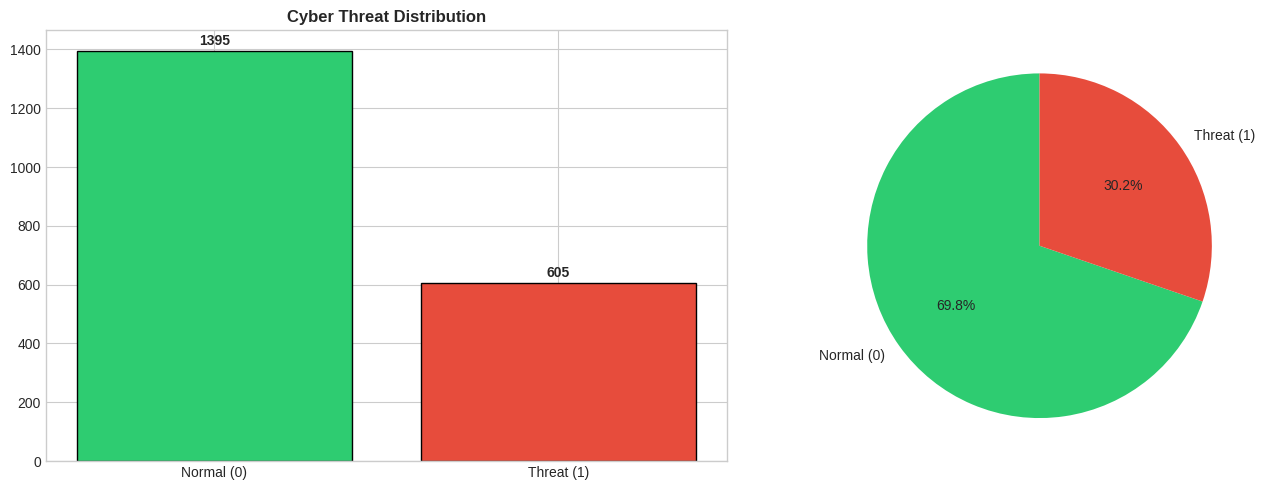

AU: ACSC responded to 1,100+ cyber incidents in 2022-23. Essential Eight is mandatory for gov.


In [2]:
tc='threat'
print(df[tc].value_counts().sort_index())
fig,axes=plt.subplots(1,2,figsize=(14,5))
vc=df[tc].value_counts().sort_index();labels=['Normal (0)','Threat (1)'];colors=['#2ecc71','#e74c3c']
axes[0].bar(range(2),vc.values,color=colors,edgecolor='black')
axes[0].set_xticks(range(2));axes[0].set_xticklabels(labels)
axes[0].set_title('Cyber Threat Distribution',fontweight='bold')
for i,v in enumerate(vc.values): axes[0].text(i,v+20,str(v),ha='center',fontweight='bold')
axes[1].pie(vc.values,labels=labels,autopct='%1.1f%%',colors=colors,startangle=90)
plt.tight_layout();plt.savefig('target.png',dpi=150);plt.show()
print("AU: ACSC responded to 1,100+ cyber incidents in 2022-23. Essential Eight is mandatory for gov.")

## 3. EDA

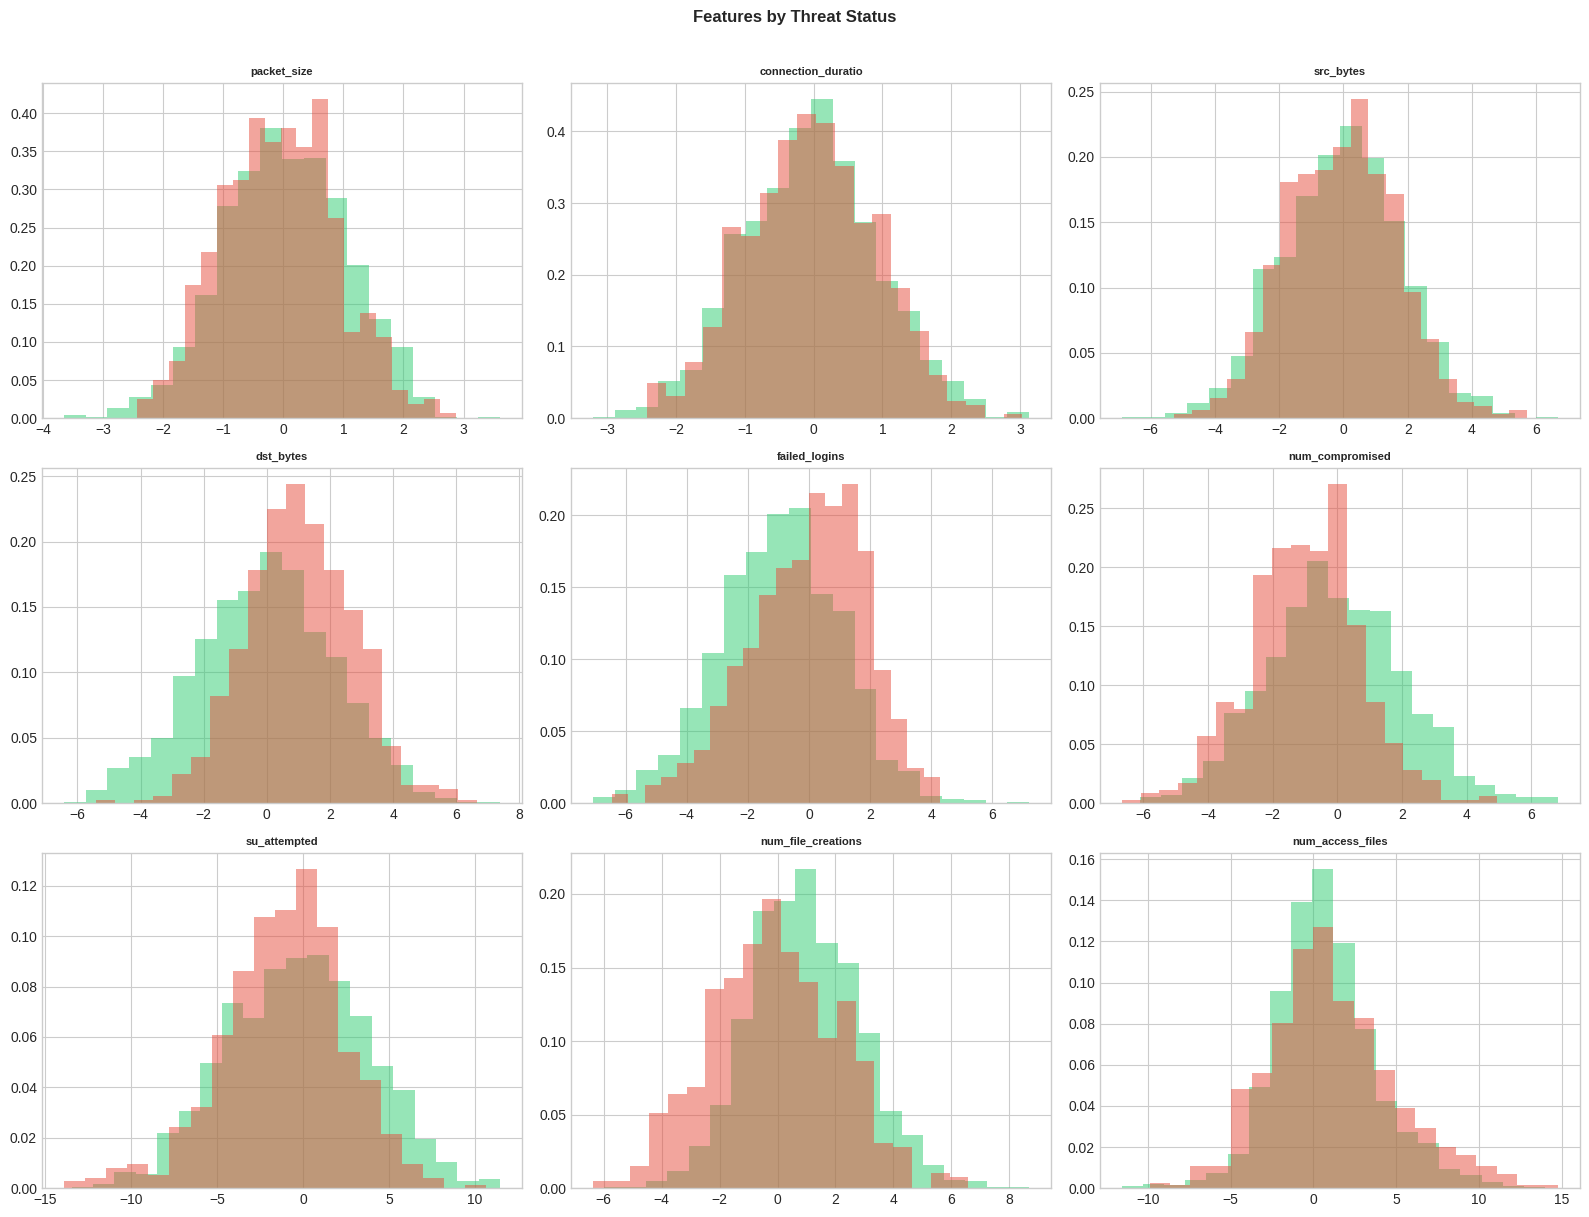

In [3]:
nums=[c2 for c2 in df.columns if c2!=tc]
fig,axes=plt.subplots(3,3,figsize=(16,12));axes=axes.flatten()
for i,col in enumerate(nums[:9]):
    for l,clr in zip([0,1],colors):
        s=df[df[tc]==l][col];axes[i].hist(s,bins=20,alpha=0.5,density=True,color=clr)
    axes[i].set_title(col[:18],fontsize=8,fontweight='bold')
plt.suptitle('Features by Threat Status',fontweight='bold',y=1.01)
plt.tight_layout();plt.savefig('eda.png',dpi=150);plt.show()

## 4. Training

In [4]:
X=df[nums];y2=df[tc].values
try:
    from xgboost import XGBClassifier
except: XGBClassifier=None
try:
    from lightgbm import LGBMClassifier
except: LGBMClassifier=None
models={'LogReg':LogisticRegression(max_iter=2000,random_state=42),'RF':RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)}
if XGBClassifier: models['XGB']=XGBClassifier(n_estimators=100,random_state=42,eval_metric='logloss',use_label_encoder=False,verbosity=0,n_jobs=-1)
if LGBMClassifier: models['LGBM']=LGBMClassifier(n_estimators=100,random_state=42,verbose=-1,n_jobs=-1,force_col_wise=True)
skf=StratifiedKFold(3,shuffle=True,random_state=42);Xa=X.values;results={}
for mn,mod in models.items():
    print(f"\n{'='*50}\n{mn}\n{'='*50}")
    fa,ff,fu=[],[],[];fp=np.zeros(len(y2),dtype=int);fpr=np.zeros(len(y2));t0=time.time()
    for fi,(ti,vi) in enumerate(skf.split(Xa,y2)):
        m2=type(mod)(**mod.get_params());m2.fit(Xa[ti],y2[ti]);yp=m2.predict(Xa[vi]);yb=m2.predict_proba(Xa[vi])[:,1]
        fp[vi]=yp;fpr[vi]=yb;a=accuracy_score(y2[vi],yp);f=f1_score(y2[vi],yp);u=roc_auc_score(y2[vi],yb)
        fa.append(a);ff.append(f);fu.append(u);print(f"  Fold{fi+1}: Acc={a:.4f} F1={f:.4f} AUC={u:.4f}")
    el=time.time()-t0;results[mn]={'acc':np.mean(fa),'f1':np.mean(ff),'auc':np.mean(fu),'time':el,'preds':fp}
    print(f"  AVG: Acc={np.mean(fa):.4f} F1={np.mean(ff):.4f} AUC={np.mean(fu):.4f}")


LogReg
  Fold1: Acc=0.8741 F1=0.7730 AUC=0.9373
  Fold2: Acc=0.8546 F1=0.7557 AUC=0.9039
  Fold3: Acc=0.8529 F1=0.7407 AUC=0.9067
  AVG: Acc=0.8605 F1=0.7565 AUC=0.9160

RF
  Fold1: Acc=0.9145 F1=0.8455 AUC=0.9687
  Fold2: Acc=0.8996 F1=0.8269 AUC=0.9524
  Fold3: Acc=0.9039 F1=0.8251 AUC=0.9586
  AVG: Acc=0.9060 F1=0.8325 AUC=0.9599

XGB
  Fold1: Acc=0.9280 F1=0.8750 AUC=0.9783
  Fold2: Acc=0.9115 F1=0.8578 AUC=0.9660
  Fold3: Acc=0.9264 F1=0.8734 AUC=0.9695
  AVG: Acc=0.9220 F1=0.8687 AUC=0.9713

LGBM
  Fold1: Acc=0.9220 F1=0.8646 AUC=0.9768
  Fold2: Acc=0.9175 F1=0.8655 AUC=0.9673
  Fold3: Acc=0.9189 F1=0.8622 AUC=0.9637
  AVG: Acc=0.9195 F1=0.8641 AUC=0.9693


## 5. Comparison & Error Analysis

COMPARISON
 Model    Acc     F1    AUC
   XGB 0.9220 0.8687 0.9713
  LGBM 0.9195 0.8641 0.9693
    RF 0.9060 0.8325 0.9599
LogReg 0.8605 0.7565 0.9160

Best: XGB


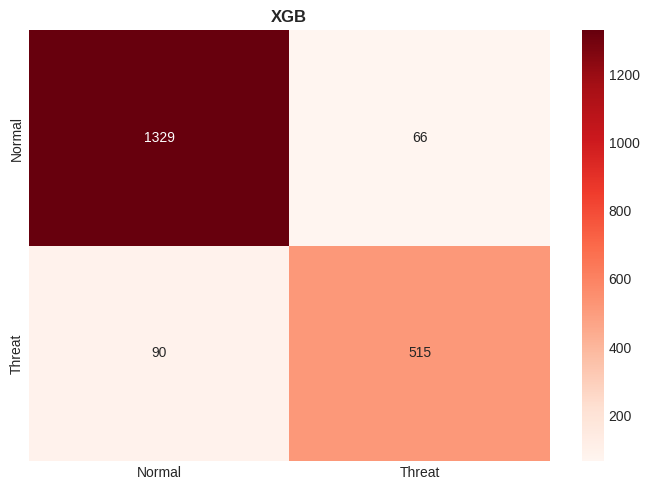

              precision    recall  f1-score   support

      Normal       0.94      0.95      0.94      1395
      Threat       0.89      0.85      0.87       605

    accuracy                           0.92      2000
   macro avg       0.91      0.90      0.91      2000
weighted avg       0.92      0.92      0.92      2000



In [5]:
rows=[{'Model':k,'Acc':f"{v['acc']:.4f}",'F1':f"{v['f1']:.4f}",'AUC':f"{v['auc']:.4f}",'s':v['auc']} for k,v in results.items()]
sdf=pd.DataFrame(rows).sort_values('s',ascending=False);best=sdf.iloc[0]['Model']
print("COMPARISON");print("="*60);print(sdf[['Model','Acc','F1','AUC']].to_string(index=False));print(f"\nBest: {best}")
bp=results[best]['preds'];cm=confusion_matrix(y2,bp)
fig,ax=plt.subplots(figsize=(7,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Reds',xticklabels=['Normal','Threat'],yticklabels=['Normal','Threat'],ax=ax)
ax.set_title(f'{best}',fontweight='bold')
plt.tight_layout();plt.savefig('cm.png',dpi=150);plt.show()
print(classification_report(y2,bp,target_names=['Normal','Threat']))

## 6. Feature Importance & Deployment

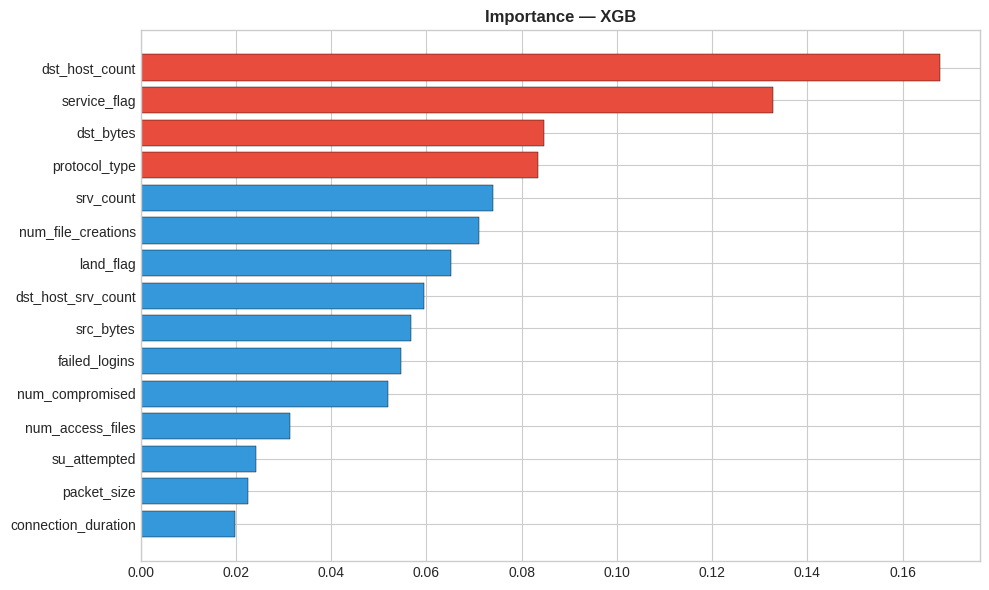

DEPLOYMENT READINESS
  Model: XGB  AUC: 0.9713  F1: 0.8687
  Feats: 15  Rows: 2,000
  [pass] AUC>0.90
  [pass] F1>0.80
  [pass] CV
  APPROVED

Architecture: SIEM/SOC logs -> ASD threat intel -> Fabric -> real-time threat detection


In [6]:
tm={k:v for k,v in models.items() if k!='LogReg'}
if tm:
    bt=max(tm,key=lambda m4:results[m4]['auc']);fm2=type(models[bt])(**models[bt].get_params());fm2.fit(Xa,y2)
    fi=pd.DataFrame({'Feature':X.columns,'Imp':fm2.feature_importances_}).sort_values('Imp')
    fig,ax=plt.subplots(figsize=(10,6))
    ax.barh(fi['Feature'],fi['Imp'],color=['#e74c3c' if v>fi['Imp'].quantile(0.75) else '#3498db' for v in fi['Imp']],edgecolor='black',linewidth=0.3)
    ax.set_title(f'Importance — {bt}',fontweight='bold')
    plt.tight_layout();plt.savefig('imp.png',dpi=150);plt.show()
br=results[best]
print("="*60);print("DEPLOYMENT READINESS");print("="*60)
print(f"  Model: {best}  AUC: {br['auc']:.4f}  F1: {br['f1']:.4f}")
print(f"  Feats: {X.shape[1]}  Rows: {len(y2):,}")
checks={'AUC>0.90':br['auc']>0.90,'F1>0.80':br['f1']>0.80,'CV':True}
ap=all(checks.values())
for k,v in checks.items(): print(f"  [{'pass' if v else 'FAIL':4s}] {k}")
print("  APPROVED" if ap else "  FAILED")
print("\nArchitecture: SIEM/SOC logs -> ASD threat intel -> Fabric -> real-time threat detection")